# Getting Started with Pyomo.DoE

Model-based design uses physics-based models. It starts with prior knowledge and iterates through the loop until a satisfactory model is found. We have already discussed parameter estimation in the first part of the workshop. If we have multiple models, we can discriminate among them to find the best model that fits the data. However, that is not a part of this workhsop. 

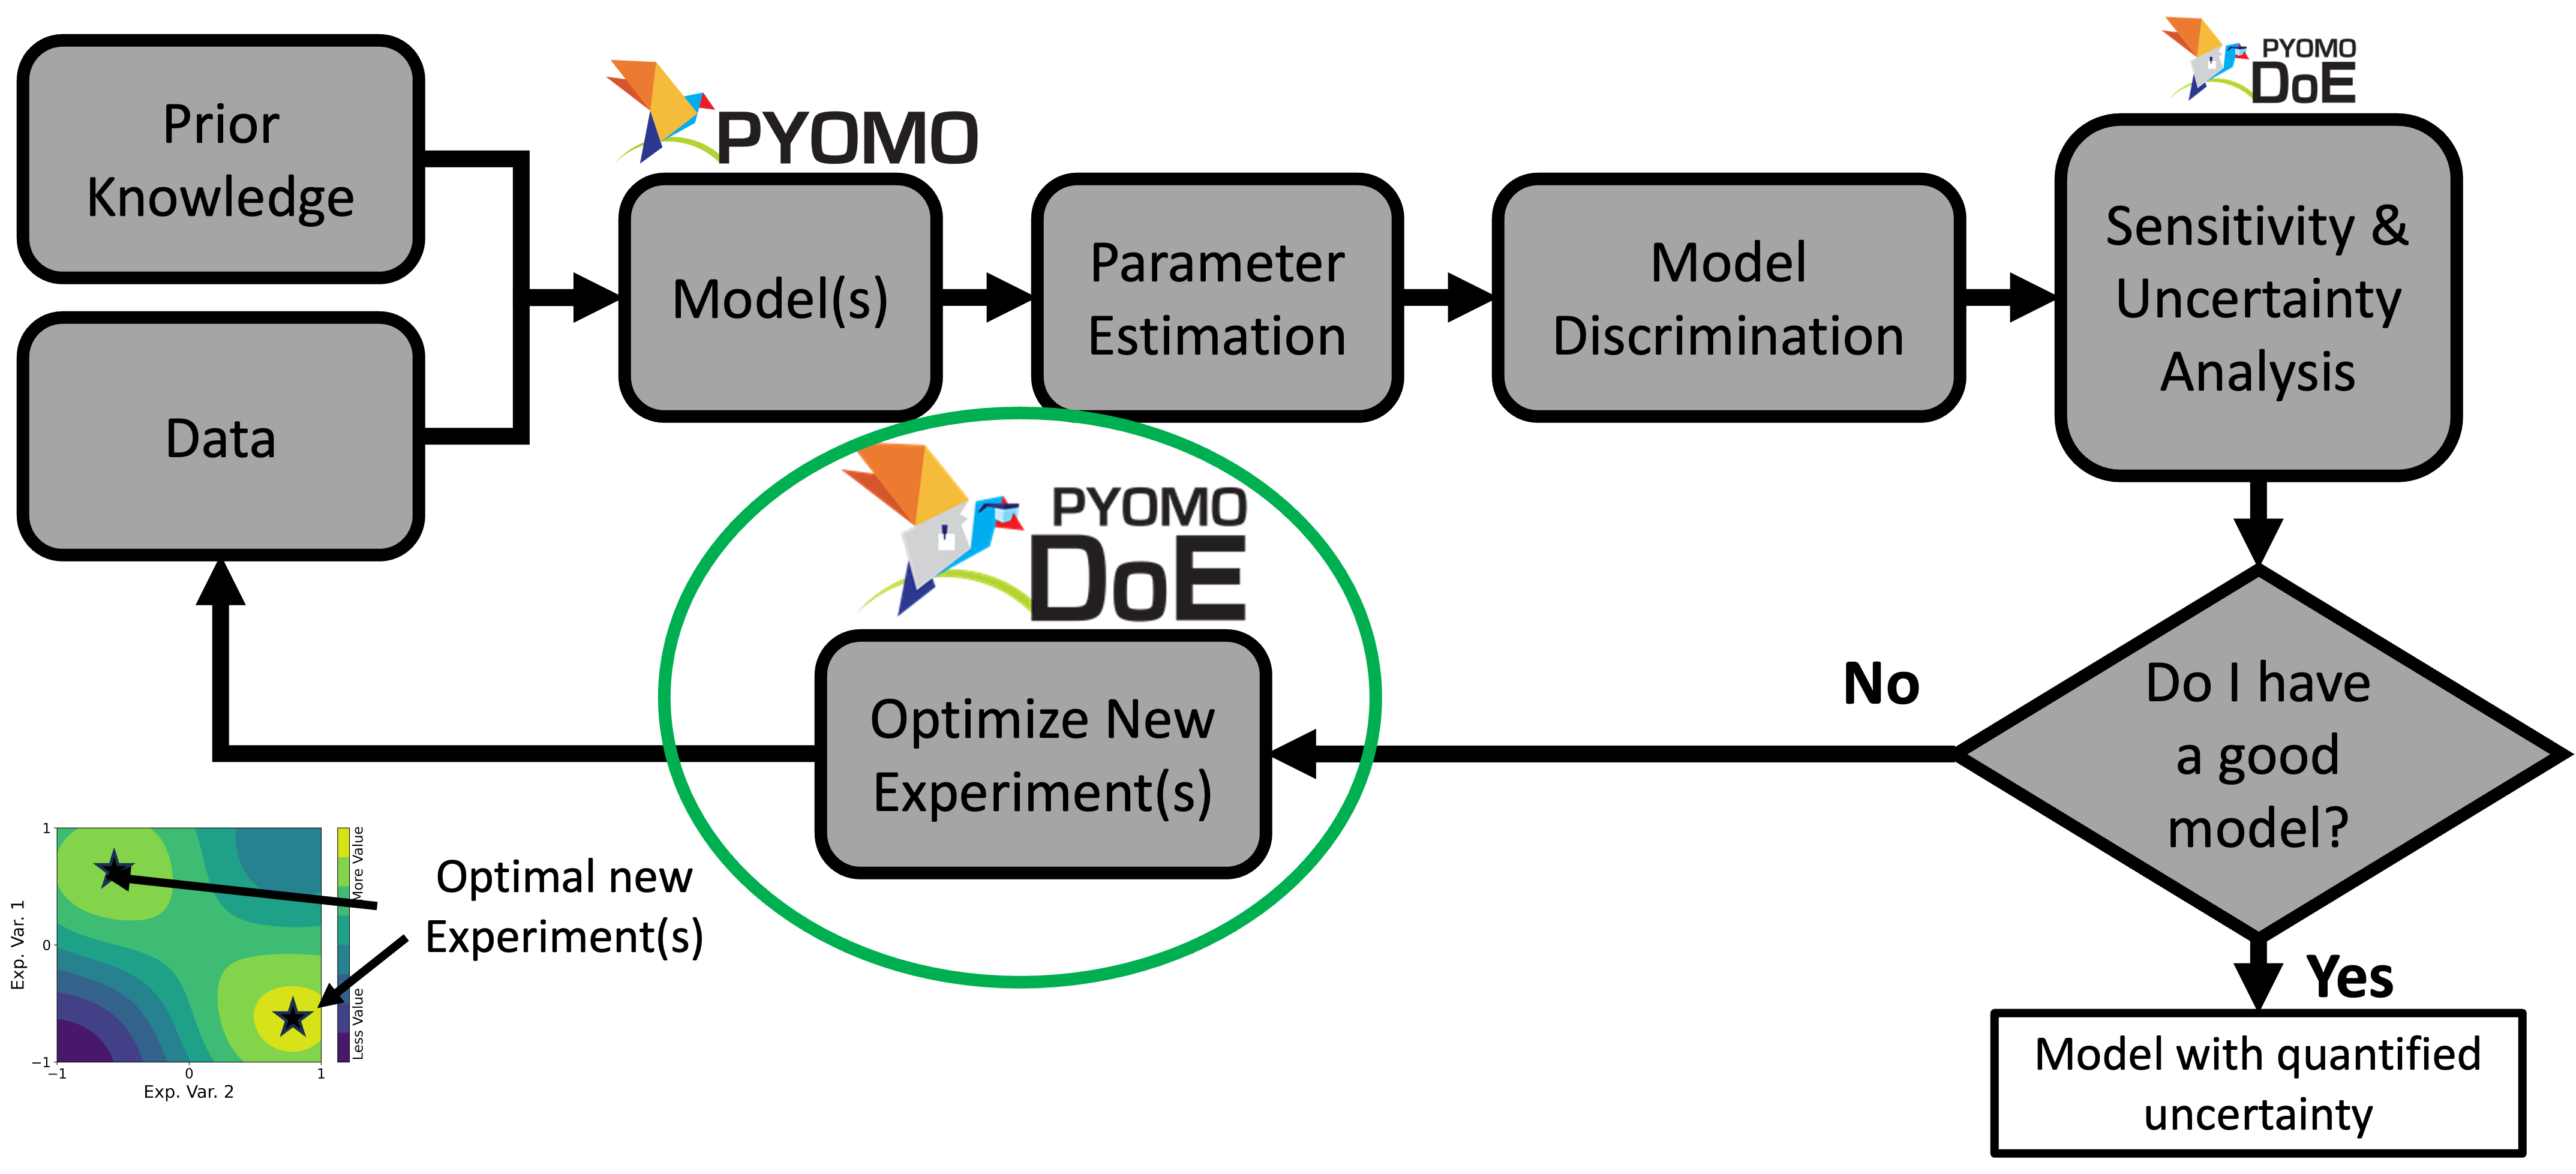

In the `optimize new experiments` step, we can design a single experiment (sequential design), or we can design multiple experiments (multi-experiment design). We will discuss both in this workshop.
## Fisher information matrix
The covariance matrix ($V$) can be approximated as the inverse of the Fisher information matrix ($M$). Mathematically,
$$
\mathbf{V}(\hat{\boldsymbol{\theta}}) \approx \mathbf{M}(\hat{\boldsymbol{\theta}})^{-1}
$$
For a normally distriuted measurement error, the Fisher information matrix (FIM) can be defined as 
$$
\mathbf{M} = (\nabla_{\boldsymbol{\theta}} \hat{\mathbf{y}})^{\top} \Sigma_y^{-1} \nabla_{\boldsymbol{\theta}} \hat{\mathbf{y}}
$$
 Where, 
- $\hat{\mathbf{y}}$ is the vector of model responses
- $\boldsymbol{\theta}$ is the vector of nominal parameters
- $\Sigma_y$ is the measurement error

## Optimization Formulation
Maximize a scalar-valued function $\psi(\cdot)$ of the Fisher information matrix $\mathbf{M}$:

$$
\begin{align*}
\max_{u} \quad & \psi(\mathbf{M}(u) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t)\\
& C_p^S \frac{dT_S}{dt} = U_b (T_H - T_S)  \\
& 0\% \leq u(t) \leq 100 \% \\
& T_H(t_0) = T_{amb} \\
& T_S(t_0) = T_{amb}
\end{align*}
$$

`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for $\psi(\cdot) = \log_{10}(\mathrm{trace}(FIM))$, i.e., pseudo A-optimality. There are other many other optimality criteria. A-, D-, E, and ME-optimality will be presented later. In this section, we will see how to design an experiment using pseudo A-optimality

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)

We load the sine-test experimental data to initialize the model. Our `create_model` function uses the supplied data to set initial values for the Pyomo variables. Careful initialization is often important when solving large-scale dynamic optimization problems.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


For completeness, we will visualize the data again.

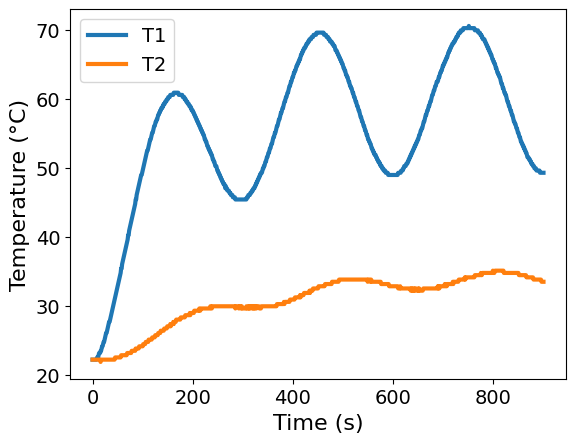

In [3]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

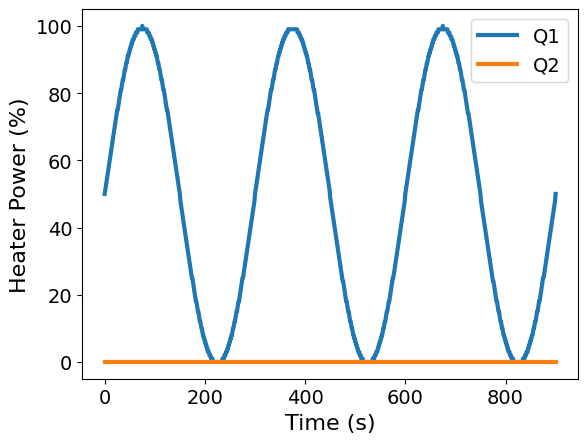

In [4]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

And then we will store the data in an instance of our `TC_Lab_data` dataclass to help us organize the data.

In [5]:
# Here, we will induce a step size of 6 seconds, as to not to make the problem too large,
#  so that we can solve the problem in manageable time.
skip = 6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Use prior parameter information

As shown earlier, the model is not estimable in its original form, so we used regularization in the previous notebook. Here, we reuse the resulting parameter estimates and covariance matrix as prior information for experimental design.

In [6]:
import numpy as np

# Theta values estimated from the regularized regresssion in the previous notebook
# L2 regularization
theta_values = {
    'Ua': 0.041007,
    'Ub': 0.014152,
    'inv_CpH': 0.170600,
    'inv_CpS': 4.545456,
}

# Cov estimated from the regularized regression in the previous notebook
# L2 regularization
cov = np.array([[2.431122e-10, -1.411022e-09, 4.013878e-09, -2.421788e-11],
                [-1.411022e-09, 1.159466e-06, 5.106751e-07, -3.727706e-04],
                [4.013878e-09, 5.106751e-07, 4.906845e-07, -1.975614e-04],
                [-2.421788e-11, -3.727706e-04, -1.975614e-04, 1.249945e-01]])

# We need to pass prior FIM to the DesignOfExperiments class which we will use to 
# optimize the experiment. 
# Remember that the FIM is the inverse of the covariance matrix of the parameter 
# estimates, so we can compute it as follows:
FIM = np.linalg.inv(cov)

# Let's look at the FIM to see how informative our prior is before optimization
results_summary(FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.85058570496256
A-optimality: -0.9031033621004037
D-optimality: 25.37468441861932
E-optimality: 0.9031041488008479
Modified E-optimality: 8.941569967556886

FIM:
 [[ 6.97975943e+09 -1.87655054e+08 -2.39586954e+08 -9.38323302e+05]
 [-1.87655054e+08  8.07624513e+07  3.97586034e+07  3.03698389e+05]
 [-2.39586954e+08  3.97586034e+07  2.84888424e+07  1.63600224e+05]
 [-9.38323302e+05  3.03698389e+05  1.63600224e+05  1.17229876e+03]]

eigenvalues:
 [6.99317049e+09 9.11970383e+07 4.64435511e+06 8.00026087e+00]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9990    0.0394    0.0197   -0.0000
Ub         0.0273    0.9051   -0.4243   -0.0030
inv_CpH    0.0345    0.4234    0.9053   -0.0016
inv_CpS    0.0001    0.0034    0.0002    1.0000


From the eigendecomposition, we see that we have the least confidence in `inv_CpS` and the greatest confidence in `Ua`. We now design the next experiment to improve parameter confidence.

## Optimize next experiment (Pseudo A-optimality)

Now, create and solver object to pass to DoE so that we can control the solver behavior.

In [7]:
from pyomo.environ import SolverFactory

solver = SolverFactory("ipopt")
solver.options["max_iter"] = 1000
solver.options["tol"] = 1e-5
solver.options["linear_solver"] = "ma57"

Next, we consider pseudo A-optimality, which here is based on maximizing the trace of the Fisher information matrix.

In [8]:
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.contrib.doe.utils import rescale_FIM
theta_ref = np.array([
    theta_values["Ua"],
    theta_values["Ub"],
    theta_values["inv_CpH"],
    theta_values["inv_CpS"],
])
# Because the parameter values differ substantially in magnitude, we can use parameter 
# scaling in DesignOfExperiments to improve numerical conditioning.
RESCALE_FIM = False # Set to True if you want to rescale the FIM, False otherwise
if RESCALE_FIM:
    FIM_scaled = rescale_FIM(FIM, theta_ref)
else:
    FIM_scaled = FIM
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, 
    theta_initial=theta_values, 
    number_of_states=number_tclab_states
    )

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_pA = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-5,
                                 scale_constant_value=1,
                                 scale_nominal_param_value= RESCALE_FIM,
                                 objective_option="pseudo_trace",  
                                 # Now we specify a type of objective, A-opt = "trace"
                                 prior_FIM=FIM_scaled,  
                                 tee=True,)

TC_Lab_DoE_pA.run_doe()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

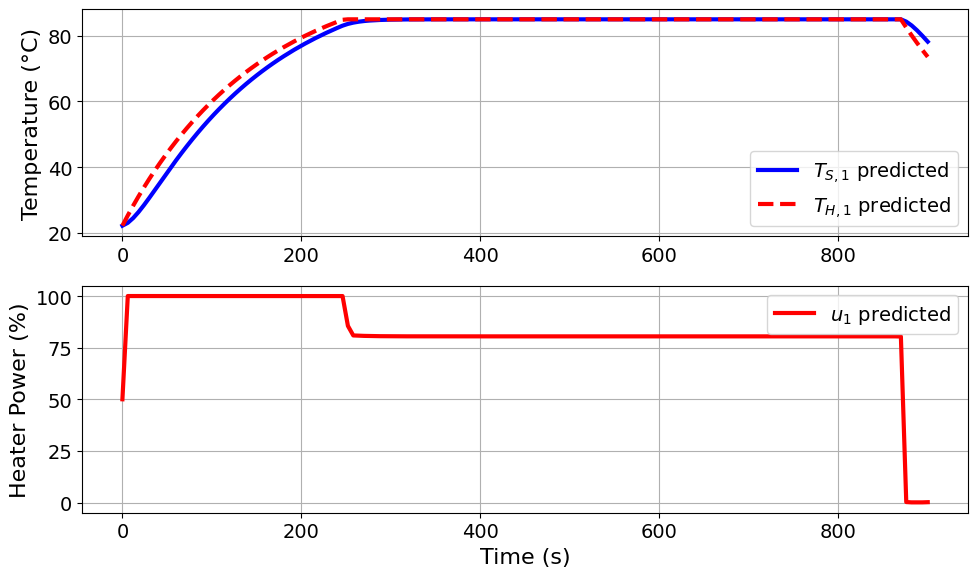

Model parameters:
Ua = 0.041 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [9]:
dopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_pA.model.fd_scenario_blocks[0])

Interesting! We get a square-tooth like structure for our pseudo-A optimal criterion. The pseudo A-optimal design drives the system to relatively high temperatures, suggesting that this region is especially informative for the chosen objective.

Recall that we used the parameter scaling in `DesignOfExperiments`. So, we need to unscale it again for a fair comparison.

In [10]:
FIM_pA = np.asarray(TC_Lab_DoE_pA.results['FIM'])
if RESCALE_FIM:
    D = np.diag(theta_ref)
    FIM_unscaled = D @ FIM_pA @ D
else:
    FIM_unscaled = FIM_pA
results_summary(np.asarray(FIM_unscaled))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.02814603836729
A-optimality: -0.9031036813348438
D-optimality: 25.997738013305405
E-optimality: 0.9031041495798382
Modified E-optimality: 9.11850754827937

FIM:
 [[ 1.04931958e+10 -2.40281503e+08 -3.44850101e+08 -1.26164503e+06]
 [-2.40281503e+08  1.32328751e+08  6.23098708e+07  4.93129085e+05]
 [-3.44850101e+08  6.23098708e+07  4.40219860e+07  2.55406202e+05]
 [-1.26164503e+06  4.93129085e+05  2.55406202e+05  1.88234585e+03]]

eigenvalues:
 [1.05102174e+10 1.51522971e+08 7.80806982e+06 8.00026089e+00]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9992    0.0350    0.0204   -0.0000
Ub         0.0233    0.9092   -0.4157   -0.0030
inv_CpH    0.0331    0.4149    0.9093   -0.0016
inv_CpS    0.0001    0.0034    0.0002    1.0000


Now, we will compare different FIM metrics before and after the experimental design. 

In [11]:
# Create a helper function to compute FIM metrics
def log10_FIM_metric(FIM):
    A_opt = np.log10(np.trace(FIM))
    D_opt = np.log10(np.linalg.det(FIM))
    E_opt = np.log10(np.min(np.linalg.eigvals(FIM)))
    ME_opt = np.log10(np.max(np.linalg.eigvals(FIM)) / np.min(np.linalg.eigvals(FIM)))
    return A_opt, D_opt, E_opt, ME_opt

In [12]:
import pandas as pd
prior_metrics = log10_FIM_metric(FIM)
optimized_metrics = log10_FIM_metric(FIM_unscaled)
metric_names = ["A_opt", "D_opt", "E_opt", "ME_opt"]

metrics_df = pd.DataFrame(
    {
        "prior": list(prior_metrics),
        "optimized": list(optimized_metrics),
    },
    index=metric_names,
)
metrics_df.index.name = "metric"

metrics_df.round(2)

,prior,optimized
metric,,
A_opt,9.85,10.03
D_opt,25.37,26.00
E_opt,0.90,0.90
ME_opt,8.94,9.12


Compared with the prior, the designed experiment substantially improves the information content of the FIM. In particular, the design appears to improve confidence in `inv_CpS` significantly.


## Sensitivity Analysis
The eigendecomposition of the FIM above shows we have the least information (and thus greatest uncertainty) about parameter $U_b$. This uncertainty motivates performing a sensitivitiy analysis of the optimal experiment design to perturbations in $U_b$.

In [13]:
import numpy as np
HIGHEST_UNCERTAINTY_PARAM = "inv_CpS"
IS_INV = HIGHEST_UNCERTAINTY_PARAM.startswith("inv_")
UNIT = "W/°C" if not IS_INV else "°C/J"
# We will vary the parameter with the highest uncertainty (Ub in this case) from 1% to 
# 200% of its original value, to see how the optimal experiment changes with respect 
# to the uncertainty in this parameter.
param_grid = np.array([theta_values[HIGHEST_UNCERTAINTY_PARAM]*0.5, 
                         theta_values[HIGHEST_UNCERTAINTY_PARAM]*0.75, 
                         theta_values[HIGHEST_UNCERTAINTY_PARAM]*1.25,
                         theta_values[HIGHEST_UNCERTAINTY_PARAM]*1.5,
                         theta_values[HIGHEST_UNCERTAINTY_PARAM]*2.0])
# Save results in arrays for plotting later
param_values = [] 
pA_opt = []
u_solutions = []
Ts_solutions = []

for i, v in enumerate(param_grid):

    print("\n********************\n" + HIGHEST_UNCERTAINTY_PARAM + " = ", v, " ", UNIT)

    theta_values_new = theta_values.copy()
    # Update the theta value with the highest uncertainty to the new value in this iteration
    theta_values_new[HIGHEST_UNCERTAINTY_PARAM] = v if not IS_INV else 1/v

    # Create experiment object for design of experiments
    doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values_new, number_of_states=number_tclab_states)

    # Create a new DoE object
    try:
        TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                        step=1e-2,
                                        scale_constant_value=1,
                                        scale_nominal_param_value=True,
                                        objective_option="pseudo_trace",  
                                        # We specify a type of objective, A-opt = "trace"
                                        prior_FIM=FIM_scaled,  
                                        tee=False,)
        
        TC_Lab_DoE.run_doe()
    except:
        print("Optimization failed for this parameter value. Skipping to the next one.")
        continue

    
    pyomo_results = extract_results(TC_Lab_DoE.model.fd_scenario_blocks[0])

    results_summary(np.asarray(TC_Lab_DoE.results['FIM']))

    

    param_values.append(float(v))
    pA_opt.append(float(np.log10(np.trace(TC_Lab_DoE.results['FIM']))))
    u_solutions.append(pyomo_results.u1)
    Ts_solutions.append(pyomo_results.TS1_data)

    print("********************\n")


********************
inv_CpS =  2.272728   °C/J
WARNING (W1002): Setting Var 'inv_CpS' to a numeric value `0.4399998592000451`
outside the bounds (1, 10).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
Optimization failed for this parameter value. Skipping to the next one.

********************
inv_CpS =  3.409092   °C/J
WARNING (W1002): Setting Var 'inv_CpS' to a numeric value `0.2933332394666967`
outside the bounds (1, 10).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
Optimization failed for this parameter value. Skipping to the next one.

********************
inv_CpS =  5.68182   °C/J
WARNING (W1002): Setting Var 'inv_CpS' to a numeric value `0.175999943680018`
outside the bounds (1, 10).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
Optimization failed for this parameter value. Skipping to the next one.

********************
inv_CpS =  6.818184   °C/J
WARNING (W1002): Setting Var 'inv_CpS' to a numeric value
`

Now let's visualize how the *Pseudo A-optimality objective* changes as a function of $U_b$.

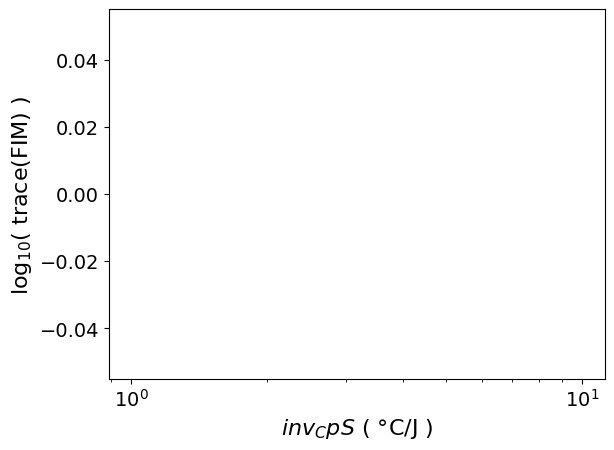

In [14]:
import matplotlib.pyplot as plt

plt.semilogx(param_values, pA_opt, marker='o')
plt.xlabel('$' + HIGHEST_UNCERTAINTY_PARAM + '$ ( ' + UNIT + ' )')
plt.ylabel('log$_{10}$( trace(FIM) )')
plt.show()

We see the objective changes insignificantly as we vary $U_b$. What about the optimal solution?

/var/folders/__/5p42xpfs2tj5j1_sgllkjwxh0000gs/T/ipykernel_49250/1427189509.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, loc='best')


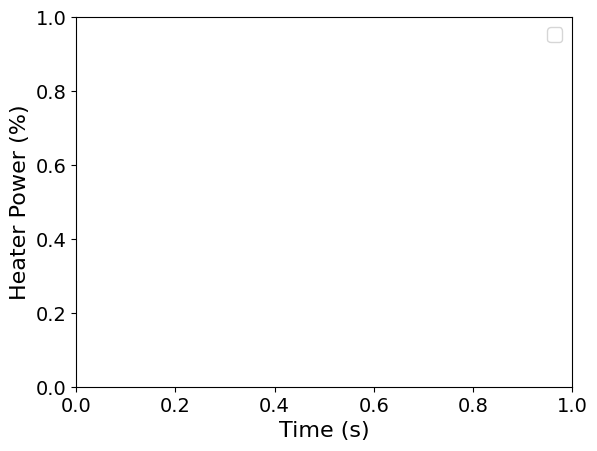

In [15]:
for i, v in enumerate(param_values):
    plt.plot(tc_data.time, u_solutions[i], label=f'${HIGHEST_UNCERTAINTY_PARAM}$ = {v:0.2e}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Heater Power (%)')
plt.show()

Interesting, the pseudo A-optimal next experiment does change on the assumed value of $U_b$. For all the values of $U_b$, the optimal solutions are similar: start around $u_1 = 100$% and then decreases as the experiment progresses. As $U_b$ increases, the length of time spent at 100% power increases by a little.

Let's also look at the optimal sensor temperature profile:

/var/folders/__/5p42xpfs2tj5j1_sgllkjwxh0000gs/T/ipykernel_49250/2029714403.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, loc='best')


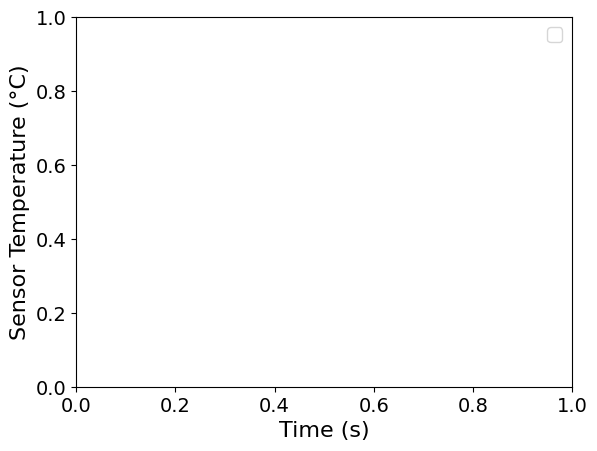

In [16]:
for i, v in enumerate(param_values):
    plt.plot(tc_data.time, Ts_solutions[i], label=f'${HIGHEST_UNCERTAINTY_PARAM}$ = {v:0.2e}')
plt.legend(ncol=2, loc='best')
plt.xlabel('Time (s)')
plt.ylabel('Sensor Temperature (°C)')
plt.show()

## Activity: Change the initial point
Careful initialization is important for most complex optimization problems. In this exericse, we will change the initial point and observe if that changes the result we got just now.

In the last experiment, we used the sine data for initialization. We will change that in our exercise.

In [17]:

skip = 6

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

We now modify the initial heater-power profile $u_1$ and check whether the optimizer converges to the same design or a different local solution.

In [18]:
from dataclasses import replace

# ------------------- Choose a new design for u1 -------------------
# Set a random seed for reproducibility
SEED: int = 101 # Choose any integer seed you like
PDF = "normal" # Choose between "normal" or "uniform" distribution for the new design of u1
# ------------------------------------------------------------------

rng = np.random.default_rng(seed=SEED)

if PDF == "normal":
    u1_design = rng.normal(loc=50.0, scale=10.0, size=len(tc_data.time))
    # Normal distribution is unbounded, so we need to clip the values to be within the 
    # bounds of the control input, which is [0, 100] in this case.
    u1_design = np.clip(u1_design, 0.0, 100.0)    
elif PDF == "uniform":
    u1_design = rng.uniform(low=0.0, high=100.0, size=len(tc_data.time))


# Create a new data object with only u1 replaced
tc_data_2 = replace(tc_data, u1=u1_design)

# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

### Optimize experiment with new initial point
Create the `DesignOfExperiments` object and optimize the next experiment with our newly initialized dataclass.

In [19]:
from pyomo.contrib.doe import DesignOfExperiments
    
# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_pA_2 = DesignOfExperiments(experiment=doe_experiment_2, 
                                 step=1e-5,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=RESCALE_FIM,
                                 objective_option="pseudo_trace",
                                 prior_FIM=FIM_scaled,
                                 tee=True)

TC_Lab_DoE_pA_2.run_doe()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

### Analyze the new result

Let's start with plotting the data from our new result.

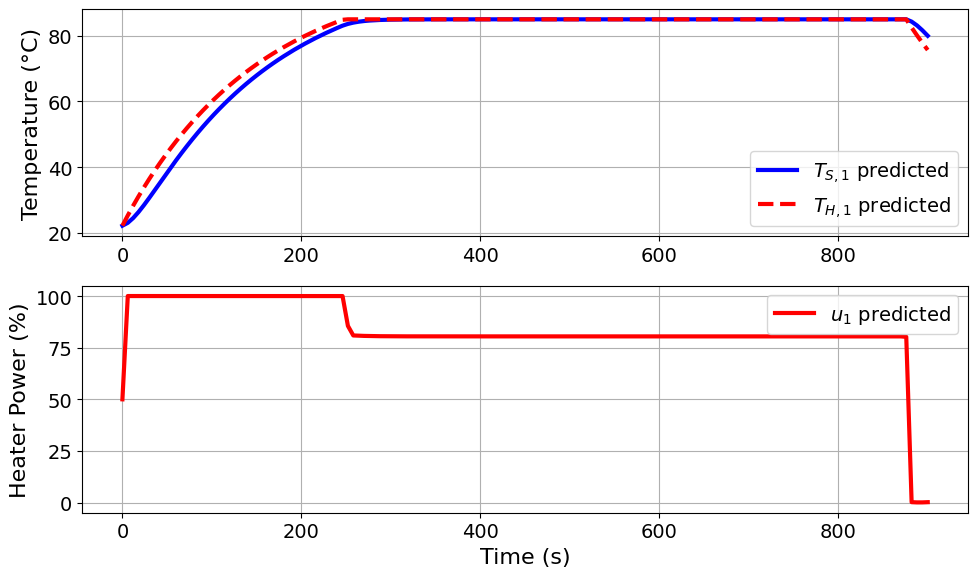

Model parameters:
Ua = 0.041 Watts/degC
Ub = 0.0142 Watts/degC
CpH = 5.8617 Joules/degC
CpS = 0.22 Joules/degC
 


In [20]:
dopt_pyomo_doe_results_2 = extract_plot_results(None, TC_Lab_DoE_pA_2.model.fd_scenario_blocks[0])

Unscale the FIM and compare the resulting design and information metrics with the previous solution.

In [21]:
FIM_pA_2 = np.asarray(TC_Lab_DoE_pA_2.results['FIM'])
if RESCALE_FIM:
    D = np.diag(theta_ref)
    FIM_unscaled_2 = D @ FIM_pA_2 @ D
else:
    FIM_unscaled_2 = FIM_pA_2
results_summary(np.asarray(FIM_unscaled_2))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.028146240827617
A-optimality: -0.9031036814927856
D-optimality: 25.99455142552758
E-optimality: 0.9031041500079424
Modified E-optimality: 9.118552789162198

FIM:
 [[ 1.04939876e+10 -2.45564609e+08 -3.45698274e+08 -1.27874165e+06]
 [-2.45564609e+08  1.31559305e+08  6.21942402e+07  4.90651890e+05]
 [-3.45698274e+08  6.21942402e+07  4.40046562e+07  2.55034180e+05]
 [-1.27874165e+06  4.90651890e+05  2.55034180e+05  1.87437130e+03]]

eigenvalues:
 [1.05113123e+10 1.50434848e+08 7.80623973e+06 8.00026090e+00]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9992    0.0355    0.0202   -0.0000
Ub         0.0238    0.9087   -0.4167   -0.0030
inv_CpH    0.0331    0.4158    0.9088   -0.0016
inv_CpS    0.0001    0.0034    0.0002    1.0000


**Discussion**: How does the new result compare to our previous analysis?